# 03 · KTPO — K-Step Test-Time Policy Optimization for Long-Horizon Discovery

**Paper:** Li, Zhao, Cao, Zhang, Gonzalez, Stoica. *KTPO: K-Step Test-Time Policy Optimization for Long-Horizon Discovery.* COLM 2026 (`papers/398_KTPO_K_Step_Test_Time_Poli.pdf`).

**Code status:** the authors' repository (`github.com/DachengLi1/KTPO`) was an *empty placeholder* (0 commits) when this notebook was written, so every mechanism below is re-implemented from Algorithm 1 and Appendix D in `notebooks/ktpo/`. The Circle Packing (n=26) seed program and validity checker are OpenEvolve's example (Apache-2.0, vendored in `notebooks/vendor/openevolve_circle_packing/`), which the paper cites as its initial program.

**What this notebook tests, block by block**

| § | Building block | Paper ref | Module |
|---|---|---|---|
| 1 | Deterministic evaluator s(·) and the seed program p₀ | Sec. 3, App. C | `ktpo/evaluator.py` |
| 2 | Program pool P: uniform parent sampling, adding valid children, eviction | Alg. 1 l.1,7,11,24 | `ktpo/pool.py` |
| 3 | Improvement reward r ∈ {+1, 0, −0.5} and GRPO group advantages | eq. (1), Sec. 3.2 | `ktpo/reward.py` |
| 4 | Improvement rate β, mastery threshold schedule τ_t, rolling buffer R, eviction threshold s̄ | eq. (2), Alg. 1 l.4,17-24 | `ktpo/reward.py` |
| 5 | MultiStepRefine: k sequential revisions with structured evaluator feedback + the verbatim App. D prompts | Sec. 3.1, App. D | `ktpo/refine.py` |
| 5b | **Same refinement run as a live coding-agent session** (pi with `read/bash/edit/write`) | Sec. 3.1 variant | `ktpo/agent.py` |
| 5c | Algorithm 1 line by line → function map, and the Refine→Train→Update-pool cycle diagram | Alg. 1 | `ktpo/viz.py` |
| 6 | Full inference-only KTPO search loop (frozen API model), with per-iteration pool snapshots, rolling buffer and per-child trajectories | Alg. 1, Fig. 2 | `ktpo/search.py` |
| 6b | Ablations: no pool, no eviction, k=1 at matched LLM budget | Sec. 4.3, Fig. 3b/3c | `ktpo/search.py` |
| 6c | The best packing found, drawn in the unit square | Fig. 4 | `ktpo/viz.py` |
| 7 | Real GRPO run (Train phase) on the local GPU | Sec. 3.2, App. B | `ktpo/grpo_train.py` |
| 8 | Training vs inference-only: average best-of-k per batch | Sec. 4.3, Fig. 3a | — |

LLM calls go to OpenRouter using the project's `.env` (`RCP_MODEL`). Set `NB_QUICK=1` to shrink budgets (and to skip §6b); `NB_ABLATIONS=0` skips §6b in a full run.

In [1]:
import os, sys, json, time, random, subprocess
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import matplotlib.pyplot as plt
import pandas as pd
common.banner()
OUT = OUTPUT_DIR / "ktpo"; OUT.mkdir(exist_ok=True)

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

## 1 · Evaluator s(·) and seed program p₀

The paper assumes "a deterministic evaluator s(·) that assigns a scalar score to candidate programs". For Circle Packing the score is the sum of radii of a *valid* packing (26 circles inside the unit square, no overlaps); invalid packings score 0. `ktpo/evaluator.py` wraps OpenEvolve's checker in a subprocess with a timeout and turns its diagnostics into the feedback string the model sees in the next refinement step (App. D.4).

In [2]:
from ktpo.evaluator import SEED_PROGRAM, evaluate, VENDOR
print((VENDOR / "COMMIT").read_text().strip(), "(OpenEvolve commit)")
print(SEED_PROGRAM[:900] + "\n...")

411fb59c886c18704caaffb611e17cf9e7d824d2 (OpenEvolve commit)
# EVOLVE-BLOCK-START
"""Constructor-based circle packing for n=26 circles"""
import numpy as np


def construct_packing():
    """
    Construct a specific arrangement of 26 circles in a unit square
    that attempts to maximize the sum of their radii.

    Returns:
        Tuple of (centers, radii, sum_of_radii)
        centers: np.array of shape (26, 2) with (x, y) coordinates
        radii: np.array of shape (26) with radius of each circle
        sum_of_radii: Sum of all radii
    """
    # Initialize arrays for 26 circles
    n = 26
    centers = np.zeros((n, 2))

    # Place circles in a structured pattern
    # This is a simple pattern - evolution will improve this

    # First, place a large circle in the center
    centers[0] = [0.5, 0.5]

    # Place 8 circles around it in a ring
    for i in range(8):
        angle = 2 * np.pi * i / 8
        centers[i + 1] = [0.5 + 0.3 * np.c
...


In [3]:
seed_result = evaluate(SEED_PROGRAM)
seed_result

Result(score=0.9597642169962064, valid=True, feedback='this_step=0.9598 validity=True boundary_violations=0 overlaps=0', sum_radii_raw=0.9597642169962064, boundary_violations=0, overlaps=0, error=None)

The seed scores ≈0.96: OpenEvolve's initial program is a deliberately weak concentric layout (the human record is 2.634, AlphaEvolve 2.635). Two negative controls show the evaluator failing closed the way the paper's reward needs it to (invalid → score 0 plus a diagnostic):

In [4]:
broken_overlap = SEED_PROGRAM.replace("radii = compute_max_radii(centers)", "radii = compute_max_radii(centers) * 1.5  # overlaps!")
broken_crash = SEED_PROGRAM.replace("n = 26", "n = 26\n    raise IndexError('list index out of range')")
for name, src in [("overlap", broken_overlap), ("crash", broken_crash)]:
    r = evaluate(src); print(f"{name:8s} score={r.score:.4f} valid={r.valid} feedback={r.feedback}")

overlap  score=0.0000 valid=False feedback=this_step=0.0000 validity=False boundary_violations=15 overlaps=8 (raw sum_radii=1.4396, score set to 0 because the packing is invalid)
crash    score=0.0000 valid=False feedback=error=list index out of range


## 2 · Program pool P

Algorithm 1: P starts as {p₀}; parents are sampled *uniformly* from P (line 7); every intermediate refinement with positive score is added (line 11); after each iteration `P ← {p : s(p) ≥ s̄}` (line 24). The test below drives the pool with synthetic programs so the mechanics are visible without any model call.

In [5]:
from ktpo.pool import Program, ProgramPool
show_source(ProgramPool.evict)
rng = random.Random(0)
pool = ProgramPool.from_seed(SEED_PROGRAM, seed_result.score)
# synthetic children: distinct sources with scores spread between 0 and 2.4 (invalid ones have score 0)
for i, sc in enumerate([0.0, 1.2, 1.9, 0.0, 2.1, 2.4, 1.0]):
    added = pool.add(Program(f"# child {i}\n" + SEED_PROGRAM, sc, parent="seed", iteration=1, origin="child"))
    print(f"child {i} score={sc:.1f} added={added}")
print("pool scores:", pool.scores)
print("uniform sample of 5 parents:", [round(p.score, 2) for p in pool.sample(rng, 5)])
evicted = pool.evict(threshold=1.5)
print("after evict(s̄=1.5):", pool.scores, "| evicted", [round(p.score, 2) for p in evicted])

**ProgramPool.evict**

```python
    def evict(self, threshold: float, keep_best: bool = True) -> list[Program]:
        """P ← {p ∈ P : s(p) ≥ s̄}. The best program is always retained so P never empties."""
        best = self.best
        evicted = [p for p in self.programs.values() if p.score < threshold and not (keep_best and p is best)]
        for p in evicted:
            del self.programs[p.pid]
        return evicted

```

child 0 score=0.0 added=False
child 1 score=1.2 added=True
child 2 score=1.9 added=True
child 3 score=0.0 added=False
child 4 score=2.1 added=True
child 5 score=2.4 added=True
child 6 score=1.0 added=True
pool scores: [2.4, 2.1, 1.9, 1.2, 1.0, 0.9597642169962064]
uniform sample of 5 parents: [2.1, 2.1, 0.96, 1.9, 2.4]
after evict(s̄=1.5): [2.4, 2.1, 1.9] | evicted [0.96, 1.2, 1.0]


## 3 · Improvement reward and GRPO advantages

$$r_j=\begin{cases}+1 & s_j^* > s(p_i)\\ 0 & \text{valid but } s_j^*\le s(p_i)\\ -0.5 & \text{invalid}\end{cases}\qquad \hat A_j=\frac{r_j-\bar r}{\sigma_r}$$

where $s_j^*=\max_{\ell\le k} s(c_j^{(\ell)})$ is the best score across the k revision steps of child j, and advantages are normalised within one parent's group of N children.

In [6]:
from ktpo.reward import reward, grpo_advantages
show_source(reward)
cases = [("beats parent", 2.30, 2.20, True), ("valid, no gain", 2.10, 2.20, True), ("equal score", 2.20, 2.20, True), ("invalid", 0.0, 2.20, False)]
rows = [{"case": n, "s*": s, "s(parent)": p, "valid": v, "reward": reward(s, p, v)} for n, s, p, v in cases]
display(df(rows))
group = [reward(s, p, v) for _, s, p, v in cases]
print("group rewards", group, "→ advantages", [round(a, 3) for a in grpo_advantages(group)])
print("all-equal group →", grpo_advantages([0.0, 0.0, 0.0, 0.0]), "(no learning signal, as in GRPO)")

**reward**

```python
def reward(best_child_score: float, parent_score: float, valid: bool) -> float:
    """Equation (1). ``best_child_score`` is s*_j = max over the k revision steps."""
    if not valid:
        return INVALID_PENALTY
    return 1.0 if best_child_score > parent_score else 0.0

```

,case,s*,s(parent),valid,reward
0,beats parent,2.3,2.2,True,1.0
1,"valid, no gain",2.1,2.2,True,0.0
2,equal score,2.2,2.2,True,0.0
3,invalid,0.0,2.2,False,-0.5


group rewards [1.0, 0.0, 0.0, -0.5] → advantages [1.606, -0.229, -0.229, -1.147]
all-equal group → [0.0, 0.0, 0.0, 0.0] (no learning signal, as in GRPO)


## 4 · Improvement rate β, threshold schedule τ_t, rolling buffer, eviction threshold s̄

$$\beta_i=\frac1N\sum_{j=1}^N \mathbb 1[s^*_{i,j}>s(p_i)]\qquad \tau_t=\tau_0+(\tau_T-\tau_0)\,t/T\qquad \bar s=\mathrm{mean}(\mathcal R[\text{last }W])$$

A parent is *mastered* when β_i ≥ τ_t; its score enters the rolling buffer R; the eviction threshold is the mean of the last W mastered scores. Paper defaults: τ₀=0.3 → τ_T=0, W=10.

**EvictionTracker**

```python
@dataclass
class EvictionTracker:
    """Rolling buffer R of mastered-parent scores and the resulting eviction threshold s̄."""

    window: int = 10
    mastered: list[float] = field(default_factory=list)

    def record_if_mastered(self, beta: float, parent_score: float, tau_t: float) -> bool:
        if beta >= tau_t:
            self.mastered.append(parent_score)
            return True
        return False

    @property
    def threshold(self) -> float | None:
        recent = self.mastered[-self.window:]
        return statistics.fmean(recent) if recent else None

```

β examples: 0.5 0.0


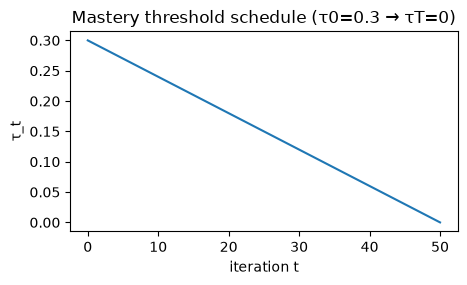

,t,τ_t,s(parent),β,mastered,R (last W),s̄
0,1,0.263,1.15,0.25,False,[],NaN
1,2,0.225,1.30,0.00,False,[],NaN
2,3,0.188,1.45,0.50,True,[1.45],1.45
3,4,0.150,1.60,0.00,False,[1.45],1.45
4,5,0.112,1.75,0.75,True,"[1.45, 1.75]",1.60
5,6,0.075,1.90,0.75,True,"[1.45, 1.75, 1.9]",1.70
6,7,0.037,2.05,0.75,True,"[1.75, 1.9, 2.05]",1.90
7,8,0.000,2.20,0.75,True,"[1.9, 2.05, 2.2]",2.05


In [7]:
from ktpo.reward import improvement_rate, mastery_threshold, EvictionTracker
show_source(EvictionTracker)
print("β examples:", improvement_rate([2.3, 2.1, 2.25, 0.0], 2.2), improvement_rate([0.0, 0.0], 2.2))
T = 50
sched = [mastery_threshold(t, T) for t in range(T + 1)]
fig, ax = plt.subplots(figsize=(5, 2.6)); ax.plot(sched); ax.set(xlabel="iteration t", ylabel="τ_t", title="Mastery threshold schedule (τ0=0.3 → τT=0)"); plt.show()

# synthetic run of the tracker: parents with rising scores, β drawn from a coin
tracker = EvictionTracker(window=3)
rng = random.Random(1)
rows = []
for t in range(1, 9):
    tau = mastery_threshold(t, 8)
    parent_score, beta = 1.0 + 0.15 * t, rng.choice([0.0, 0.25, 0.5, 0.75])
    mastered = tracker.record_if_mastered(beta, parent_score, tau)
    rows.append({"t": t, "τ_t": round(tau, 3), "s(parent)": round(parent_score, 2), "β": beta, "mastered": mastered, "R (last W)": list(map(lambda x: round(x, 2), tracker.mastered[-3:])), "s̄": None if tracker.threshold is None else round(tracker.threshold, 3)})
display(df(rows))

## 5 · MultiStepRefine (k sequential revisions with feedback) — live model calls

Appendix D gives the exact prompt scaffold: a system message, a task context, the output-format rule ("COMPLETE, SELF-CONTAINED program as a single ```python code block"), the reward rules shown to the model, and a structured feedback message between steps that carries the step counter, this step's score/validity or error, the reference score, and all scores so far. `ktpo/refine.py` reproduces these verbatim where the paper prints them.

In [8]:
from ktpo import refine
print(refine.SYSTEM_MESSAGE, "\n---\n", refine.OUTPUT_FORMAT, "\n---\n", refine.REWARD_RULES)

You are an expert software developer tasked with iteratively improving a codebase. Your job is to analyze the current program and suggest improvements based on feedback from previous attempts. Focus on making targeted changes that will increase the program's performance metrics. 
---
 Output the COMPLETE, SELF-CONTAINED program as a single ```python code block. Your code block MUST include ALL imports, ALL helper functions, and the main entry-point function. Do NOT output partial snippets, diffs, or incomplete code — every code block you produce will be executed as a standalone program. 
---
 You will get multiple refinement attempts. After each attempt, you will see your score and can try again. Your reward is based on the BEST score you achieve across all attempts minus your starting score. You get PENALIZED for producing INVALID programs (syntax errors, runtime errors, or constraint violations). You get PENALIZED for producing the SAME score as your previous attempt (lazy repetition

### 5a · The actual prompt and feedback texts

Below: the complete user message of step 1 (the reference program body elided), then the two App. D.4 feedback variants — a successful step and an erroring step — generated by `refine.feedback_message` and printed next to the paper's own examples. The only free part of the scaffold is the task-context paragraph, which the paper describes but does not print ("describes the packing problem, geometric insights, and the target score").

In [9]:
msg = refine.initial_user_message(SEED_PROGRAM, seed_result.score, k=3)
head, _, tail = msg.partition("```python")
print(head + "```python\n<... the 70-line reference program ...>\n```" + tail.split("```", 1)[1])

Problem: place n=26 non-overlapping circles inside the unit square [0,1]^2 to MAXIMISE the
sum of radii. The program must define `construct_packing()` returning (centers, radii, sum_radii)
with centers shape (26,2) and radii shape (26,), and keep the fixed `run_packing()` entry point.
A packing is valid only if every circle lies inside the square and no two circles overlap
(tolerance 1e-6); invalid packings score 0. The best known sum of radii is ≈2.635 (AlphaEvolve).
Useful ideas: mixed radii (a few large circles plus small gap-fillers), hexagonal/staggered
layouts, and numerical optimisation (scipy.optimize with overlap/boundary penalties, or iterative
radius growth) starting from a good initial layout. Keep runtime under ~20 seconds.

You will get multiple refinement attempts. After each attempt, you will see your score and can try again. Your reward is based on the BEST score you achieve across all attempts minus your starting score. You get PENALIZED for producing INVALID programs

In [10]:
from ktpo.evaluator import Result
ok  = Result(2.4523, True, "this_step=2.4523 validity=True boundary_violations=0 overlaps=3")
bad = Result(0.0, False, "error=IndexError: list index out of range", error="IndexError: list index out of range")
print("── ours (success step) ──"); print(refine.feedback_message(2, 8, ok, 2.3891, [2.4012, 2.4523]))
print("\n── paper App. D.4 (success) ──\n[Step 2/8, 6 remaining] this_step=2.4523 validity=True\nboundary_violations=0 overlaps=3\nReference program score: 2.3891\nYour scores so far:    2.4012 → 2.4523 (this step)")
print("\n── ours (error step) ──"); print(refine.feedback_message(3, 8, bad, 2.3891, [2.4012, 2.4523, 0.0]).splitlines()[0])
print("── paper App. D.4 (error) ──\n[Step 3/8, 5 remaining] this_step=-0.1000 error=IndexError: list index out of range")
print("\n(the paper's example prints a negative this_step because its Erdős-style tasks are lower-is-better;\n circle packing scores an invalid program 0, which is what eq. (1) turns into r = −0.5)")

── ours (success step) ──
[Step 2/8, 6 remaining] this_step=2.4523 validity=True boundary_violations=0 overlaps=3
Reference program score: 2.3891
Your scores so far:    2.4012 → 2.4523 (this step)

Think about how to improve this solution further. Output your COMPLETE revised program as a single ```python code block.

── paper App. D.4 (success) ──
[Step 2/8, 6 remaining] this_step=2.4523 validity=True
boundary_violations=0 overlaps=3
Reference program score: 2.3891
Your scores so far:    2.4012 → 2.4523 (this step)

── ours (error step) ──
[Step 3/8, 5 remaining] this_step=0.0000 error=IndexError: list index out of range
── paper App. D.4 (error) ──
[Step 3/8, 5 remaining] this_step=-0.1000 error=IndexError: list index out of range

(the paper's example prints a negative this_step because its Erdős-style tasks are lower-is-better;
 circle packing scores an invalid program 0, which is what eq. (1) turns into r = −0.5)


Now one real k-step trajectory from the seed program with the frozen API model, printing each feedback message. Same k as the search in §6 and the agent session in §5b, so the three are comparable.

In [11]:
K = 2 if QUICK else 3
t0 = time.time()
traj = refine.multistep_refine(SEED_PROGRAM, seed_result.score, k=K, verbose=False)
scores = []
for s in traj.steps:
    scores.append(s["result"].score)
    print(refine.feedback_message(s["step"], K, s["result"], seed_result.score, scores).split("\n\n")[0], "\n")
chat_secs = time.time() - t0
print(f"s* (best in trajectory) = {traj.best_score:.4f} vs parent {seed_result.score:.4f} → reward {reward(traj.best_score, seed_result.score, traj.any_valid)}  [{chat_secs:.0f}s]")

[Step 1/3, 2 remaining] this_step=2.0728 validity=True boundary_violations=0 overlaps=0
Reference program score: 0.9598
Your scores so far:    2.0728 (this step) 

[Step 2/3, 1 remaining] this_step=2.0743 validity=True boundary_violations=0 overlaps=0
Reference program score: 0.9598
Your scores so far:    2.0728 → 2.0743 (this step) 

[Step 3/3, 0 remaining] this_step=0.0000 error=Process timed out after 60 seconds
Reference program score: 0.9598
Your scores so far:    2.0728 2.0743 → 0.0000 (this step) 

s* (best in trajectory) = 2.0743 vs parent 0.9598 → reward 1.0  [152s]


In [12]:
best = traj.best_src
if best:
    print(best[:1500], "\n...")
    (OUT / "refine_best.py").write_text(best)

# EVOLVE-BLOCK-START
"""Optimized circle packing for n=26 circles using advanced layout and iterative growth"""
import numpy as np
from scipy.optimize import minimize

def construct_packing():
    """
    Construct a near-optimal arrangement of 26 circles in a unit square
    that maximizes the sum of their radii. Uses a hybrid approach:
    - Start with a proven good layout from literature (circle packing in square)
    - Apply numerical optimization to refine positions
    - Compute maximal radii using a greedy growth algorithm

    Returns:
        Tuple of (centers, radii, sum_of_radii)
    """
    n = 26
    # Known good starting configuration for 26 circles in a square
    # Based on staggered hexagonal packing + corner circles
    # We'll use a pattern with 3 rows of medium circles plus fillers
    
    # Row 1 (bottom): 5 circles
    row1_y = 0.08
    row1_x = np.linspace(0.08, 0.92, 5)
    
    # Row 2: 6 circles, staggered
    row2_y = 0.25
    row2_x = np.linspace(0.05, 0.95

## 5b · The same refine step as a live coding-agent session (pi)

KTPO's refine phase is a *chat* loop: the policy emits a whole program, the evaluator scores it, the App. D.4 feedback string is appended to the conversation, repeat k times. This section runs the same contract as a **tool-using coding agent**: a real `pi` session in a scratch directory that holds

* `program.py` — the pool parent (here P = {p₀}, so the same parent as §5), which the agent edits **in place**;
* `evaluate.py` — a small CLI wrapper around `ktpo.evaluator.evaluate` that prints exactly the App. D.4 feedback line and appends every call to `evals.jsonl`.

**Same as the paper:** the parent comes from the pool, the model gets *the evaluator's structured feedback between steps* and nothing else, the attempt budget is k, and the trajectory score is s\* = max over the evaluated steps, scored by eq. (1) against s(p_i).

**Different from the paper:** the paper's policy is a frozen (or GRPO-updated) model sampling a fixed-length k-step *trajectory* of complete programs — every step is one sampled completion, and that is what the RL update is computed on. The agent instead decides *when* to evaluate, may read files, may make partial edits (a diff, not a whole program), and can retract a bad edit; its rollout is a tool-call sequence with no fixed length and no per-step log-probs, so it is not something GRPO could be run on as written. It is the inference-time upper end of the same refine contract, useful as a reference point for what the k-step loop is worth without an agent scaffold.

In [13]:
from ktpo import agent
K_AGENT = 2 if QUICK else 3
ws = agent.setup_workspace(OUT / "pi_refine", SEED_PROGRAM, seed_result.score, k=K_AGENT)
print("workspace:", ws, "→", sorted(p.name for p in ws.iterdir()))
print("\n--- evaluate.py (the agent's only feedback channel) ---\n")
print((ws / "evaluate.py").read_text())

workspace: /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine → ['evaluate.py', 'program.py']

--- evaluate.py (the agent's only feedback channel) ---

#!/usr/bin/env python
"""KTPO evaluator CLI: score a candidate program and print the App. D.4 feedback line."""
import json, sys, time
from pathlib import Path

sys.path.insert(0, '/mnt/berstorage/RCP/rcp-platform/notebooks')
from ktpo.evaluator import evaluate
from ktpo.refine import feedback_message

PARENT_SCORE = 0.9597642169962064
K = 3
LOG = Path(__file__).resolve().parent / "evals.jsonl"

path = Path(sys.argv[1] if len(sys.argv) > 1 else "program.py")
src = path.read_text()
result = evaluate(src)
history = [json.loads(l) for l in LOG.read_text().splitlines() if l.strip()] if LOG.exists() else []
scores = [h["score"] for h in history] + [result.score]
step = len(scores)
# The App. D.4 feedback text, minus its closing "output a complete python code block" instruction
# (in the agentic setting the revised program is a

In [14]:
agent_prompt = agent.agent_prompt(seed_result.score, k=K_AGENT, python=sys.executable)
print(agent_prompt)

Problem: place n=26 non-overlapping circles inside the unit square [0,1]^2 to MAXIMISE the
sum of radii. The program must define `construct_packing()` returning (centers, radii, sum_radii)
with centers shape (26,2) and radii shape (26,), and keep the fixed `run_packing()` entry point.
A packing is valid only if every circle lies inside the square and no two circles overlap
(tolerance 1e-6); invalid packings score 0. The best known sum of radii is ≈2.635 (AlphaEvolve).
Useful ideas: mixed radii (a few large circles plus small gap-fillers), hexagonal/staggered
layouts, and numerical optimisation (scipy.optimize with overlap/boundary penalties, or iterative
radius growth) starting from a good initial layout. Keep runtime under ~20 seconds.

You get at most 3 evaluation attempts. After each attempt you will see your score and can edit again. Your reward is based on the BEST score you achieve across all attempts minus your starting score. You get PENALIZED for producing INVALID programs (sy

In [15]:
if common.pi_available():
    t0 = time.time()
    pi_run = common.run_pi(agent_prompt, cwd=ws, tools="read,bash,edit,write",
                           timeout=300 if QUICK else 600,
                           extra_args=["--append-system-prompt", refine.SYSTEM_MESSAGE], tag="pi_refine")
    agent_secs = time.time() - t0
    pi_run.show()
    if pi_run.turns == 0:
        print("the session produced no assistant turns; pi stderr tail:\n", pi_run.stderr[-600:])
else:
    pi_run, agent_secs = None, 0.0
    print("pi is not installed (npm i -g @earendil-works/pi-coding-agent) — skipping the agent session")

**pi session** · cwd `/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine` · 23 turns · 23 tool calls · 82178 in / 31446 out tokens · $0.0237 · 602s · exit -9

> **prompt:** Problem: place n=26 non-overlapping circles inside the unit square [0,1]^2 to MAXIMISE the
sum of radii. The program must define `construct_packing()` returning (centers, radii, sum_radii)
with centers shape (26,2) and radii shape (26,), and keep the fixed `run_packing()` entry point.
A packing is valid only if every circle lies inside the square and no two circles overlap
(tolerance 1e-6); invalid packings score 0. The best known sum of radii is ≈2.635 (AlphaEvolve).
Useful ideas: mixed radii (a few large circles plus small gap-fillers), hexagonal/staggered
layouts, and numerical optimisation…
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py"}
  - ↩ `# EVOLVE-BLOCK-START
  """Constructor-based circle packing for n=26 circles"""
  import numpy as np
  
  
  def construct_packing():
      """
      Construct a specific arrangement of 26 circles in a unit square
      that attempts to maximize the sum of their radii.
  
      Returns:
          Tuple of (centers, radii, sum_of_radii)
          centers: np.array of shape (26, 2) with (x, y) coordinates
          radii: np.array of shape (26) with radius of each circle
          sum_of_radii: Sum of all radii
      """
      # Initialize arrays for 26 circles
      n = 26
      centers = np.zer…`
- 💬 The starting program just places a simple ring pattern. I need to create a much better packing. The best known sum is ≈2.635. Let me think about a good strategy.

For circle packing in a unit square maximizing sum of radii (not the classic equal-circle packing), we want to place a few large circles and fill gaps with smaller ones. The theoretical maximum would have large circles nearly covering the square.

Let me use scipy.optimize to optimize. I'll start with a good initial layout and use iterative radius growth / penalty-based optimization.

Let me design a strategy:
1. Place some large cir…
- 🔧 `write` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py", "content": "# EVOLVE-BLOCK-START\n\"\"\"Constructor-based circle packing for n=26 circles - optimized via scipy.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\n\n\ndef _hex_layout(n, spacing):\n    \"\"\"Generate hexagonal (staggered) lattice points inside the unit square.\"\"\"\n    pts = []\n    vr = np.sqrt(3) * spacing / 2.0  # vertical spacing between rows\n    row = 0\n    y = spacing\n    while y < 1.0 - spacing and len(pts) < n:\n        offset = spacing / 2.0 if row % 2 …
  - ↩ `Successfully wrote 3643 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 💬 Let me check what I wrote - it seems it got truncated
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py"}
  - ↩ `# EVOLVE-BLOCK-START
  """Constructor-based circle packing for n=26 circles - optimized via scipy."""
  import numpy as np
  from scipy.optimize import minimize
  
  N = 26
  
  
  def _hex_layout(n, spacing):
      """Generate hexagonal (staggered) lattice points inside the unit square."""
      pts = []
      vr = np.sqrt(3) * spacing / 2.0  # vertical spacing between rows
      row = 0
      y = spacing
      while y < 1.0 - spacing and len(pts) < n:
          offset = spacing / 2.0 if row % 2 else 0.0
          x = spacing + offset
          while x < 1.0 - spacing and len(pts) < n:
      …`
- 💬 The file was truncated. Let me complete it.


- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && cat program.py | wc -l"}
  - ↩ `127`
- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Constructor-based circle packing for n=26 circles - optimized via scipy.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\n\n\ndef _hex_layout(n, spacing):\n    \"\"\"Generate hexagonal (staggered) lattice points inside the unit square.\"\"\"\n    pts = []\n    vr = np.sqrt(3) * spacing / 2.0\n    row = 0\n    y = spacing\n    while y < 1.0 - spacing and len(pts) < n:\n        offset = spacing / 2.0 if row % 2 else 0.0\n        x = spacing + offset\n        while x < 1.0 - spacing and len(pts) < n:\n            pts.append([x, y])…
  - ↩ `Successfully wrote 6313 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 60 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate.py program.py", "timeout": 65}
  - ❌ `(no output)
  
  Command exited with code 124`
- 💬 The optimization is too slow. Let me take a different approach - a fast iterative growth algorithm
- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Fast circle packing via iterative radius growth and position relaxation.\"\"\"\nimport numpy as np\n\nN = 26\n\n\ndef _hex_layout(spacing):\n    \"\"\"Generate hexagonal lattice points for N circles.\"\"\"\n    pts = []\n    vr = np.sqrt(3) * spacing / 2.0\n    row = 0\n    y = spacing\n    while y < 1.0 - spacing and len(pts) < N:\n        offset = spacing / 2.0 if row % 2 else 0.0\n        x = spacing + offset\n        while x < 1.0 - spacing and len(pts) < N:\n            pts.append([x, y])\n            x += spacing\n        y += vr\n        row += 1…
  - ↩ `Successfully wrote 4457 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 60 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate.py program.py", "timeout": 65}
  - ↩ `[Step 1/3, 2 remaining] this_step=1.1103 validity=True boundary_violations=0 overlaps=0
  Reference program score: 0.9598
  Your scores so far:    1.1103 (this step)
  Think about how to improve this solution further, then EDIT program.py and run this evaluator again (2 attempts left).`
- 💬 Score 1.1103, an improvement over 0.9598 but far from 2.635. My hex layout + growth is too conservative. The issue is my growth algorithm keeps radii too small because `_compute_radii` shrinks based on equal-ish circles.

Let me think differently. The key insight: I should use **mixed radii** - a few large circles plus small gap fillers. Let me think about the theoretical best layout.

For maximum sum of radii, a good approach is to optimize radii directly. Let me think about a proper optimization that runs fast enough.

Actually, let me reconsider. The best known is 2.635 for 26 circles. If a…
- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Circle packing for n=26 via full-square hexagonal layouts + scipy center optimization.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\n\n\ndef _compute_radii(centers):\n    \"\"\"Compute valid (non-overlapping, in-square) radii for given centers.\"\"\"\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n             …
  - ↩ `Successfully wrote 3742 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 40 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate.py program.py", "timeout": 45}
  - ❌ `(no output)
  
  Command exited with code 124`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 10 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nfrom scipy.optimize import minimize\nN=26\n\ndef _compute_radii(centers):\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n                d = np.hypot(centers[i, 0] - centers[j, 0],\n                         …
  - ↩ `10 iters took 1.26s, status=False, nfev=742`
- 💬 L-BFGS-B with 400 maxiter is far too slow (1.26s for just 10 iters, and each has ~74 evals for gradient). With 8 inits * 400 iters it'll be minutes. I need a much faster approach.

Let me reconsider. The gradient computation is the bottleneck (74 evals per iteration due to finite differences on 52 variables). 

Options:
1. Reduce variables - optimize fewer things.
2. Use a method with analytic structure.
3. Reduce number of inits and iterations drastically.

Let me instead do a smarter algorithm. The real issue is I need a good packing, not necessarily heavy optimization. Let me think about a …
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nN=26\n\ndef _compute_radii(centers):\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n                d = np.hypot(centers[i, 0] - centers[j, 0],\n                             centers[i, 1] - centers[j, 1])\n …
  - ↩ `6 6 -> 1.2203
  5 6 -> 1.2003
  6 5 -> 1.3956
  7 6 -> 1.1434
  6 7 -> 1.003
  5 7 -> 1.053
  7 5 -> 1.3307
  8 5 -> 1.2316
  5 8 -> 0.9376
  7 4 -> 1.4212
  4 7 -> 0.9782
  BEST (7, 4, np.float64(1.4212433893592533))`
- 💬 The fixed hex gives only 1.42. The issue is that `_compute_radii` uses proportional shrinking which is suboptimal. Let me implement a proper "max feasible radii" computation and just use a well-designed hex layout. Let me also try a denser packing approach
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\n\ndef _max_feasible_radii(centers):\n    '''Compute max possible radii for given centers.'''\n    n = len(centers)\n    # start with boundary limits\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    # Iteratively enforce: r_i = min(r_i, min_{j!=i} (d_ij - r_j))\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n    …
  - ↩ `6x6: prop=1.2203 maxfeas=-1.8295
  5x6: prop=1.2003 maxfeas=-1.3895
  6x5: prop=1.3956 maxfeas=-1.3100
  7x5: prop=1.3307 maxfeas=-1.9690
  7x4: prop=1.4212 maxfeas=-0.9102
  8x5: prop=1.2316 maxfeas=-2.1796
  8x4: prop=1.2809 maxfeas=-1.6564`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nimport time\n\nN=26\n# Create a test set of centers\npts = np.random.random((N,2))*0.8+0.1\n\ndef _compute_radii(centers):\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n                d = np.hypot(centers[…
  - ↩ `1000 calls: 1.335s, per call: 1.335ms, avg r sum: 1.0492`
- 💬 The _compute_radii approach is too slow per call (1.3ms). Let me use a direct penalty-based objective (vectorized, ~0.1ms per call) with L-BFGS-B. This should be fast enough.


- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Circle packing for n=26 via scipy penalty optimization + fast vectorized objective.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\nWB = 500.0    # boundary penalty weight\nWO = 2000.0   # overlap penalty weight\n\n\ndef _hex_patch(rows, cols, margin=0.008, fill=0.95):\n    \"\"\"Full-square hex lattice, scaled to fill [margin, 1-margin].\"\"\"\n    pts = []\n    h = 2.0 / np.sqrt(3.0)\n    v = 1.0\n    for j in range(rows):\n        y = j * v\n        off = h / 2.0 if j % 2 else 0.0\n        for i in range(cols):\n            …
  - ↩ `Successfully wrote 4806 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 45 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate.py program.py", "timeout": 50}
  - ↩ `[Step 2/3, 1 remaining] this_step=1.9196 validity=True boundary_violations=0 overlaps=0
  Reference program score: 0.9598
  Your scores so far:    1.1103 → 1.9196 (this step)
  Think about how to improve this solution further, then EDIT program.py and run this evaluator again (1 attempts left).`
- 💬 Score 1.9196 now, up from 1.1103. Still below 2.635. Let me improve further.

The penalty optimization works but the initial radii (0.4 * boundary) may be too small, and phase 3 with heavy penalties makes radii small. The key issue: my objective with penalty weights might converge to a state where radii are modest.

Let me think about how to push higher. The problem is the boundary penalty. When circles are tangent to the square boundary, radii can be larger. But the optimizer with heavy penalty keeps circles well inside (margin 0.001) limiting radii.

Let me improve by:
1. Better initial gues…
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nimport timeit\nN=26\ndef _objective(x, n, wb, wo):\n    c = x[:2 * n].reshape(n, 2)\n    r = x[2 * n:]\n    left = np.maximum(0, r - c[:, 0])\n    right = np.maximum(0, c[:, 0] + r - 1.0)\n    bottom = np.maximum(0, r - c[:, 1])\n    top = np.maximum(0, c[:, 1] + r - 1.0)\n    bp = np.sum(left*left + right*right + bottom*bottom + top*top)\n    dx = c[:, None, 0] - c[None, :, 0]\n    dy = c[:, None, 1] - c[None, :, 1]\n    d…
  - ↩ `0.0662 ms/call`
- 💬 Each objective call is 0.066ms. With ~78 evals per gradient, that's 5.1ms per iter. 300 iters = 1.5s per init. I can run many inits! Let me write a multi-restart version
- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Circle packing for n=26 via multi-restart scipy penalty optimization.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\n\n\ndef _objective(x, n, wb, wo):\n    \"\"\"Vectorized penalty objective: -sum(radii) + boundary + overlap penalties.\"\"\"\n    c = x[:2 * n].reshape(n, 2)\n    r = x[2 * n:]\n    # Boundary violations (squared)\n    left = np.maximum(0, r - c[:, 0])\n    right = np.maximum(0, c[:, 0] + r - 1.0)\n    bottom = np.maximum(0, r - c[:, 1])\n    top = np.maximum(0, c[:, 1] + r - 1.0)\n    bp = np.sum(left * left + …
  - ↩ `Successfully wrote 5941 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 💬 Let me time it first to make sure it stays under 20s before running the full evaluator (I have 1 attempt left and don't want to waste it).


- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 25 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport time\nt0=time.time()\nimport program\nc,r,s=program.construct_packing()\nprint(f'sum={s:.4f} time={time.time()-t0:.2f}s valid_bound={np.all(r<=np.minimum.reduce([c[:,0],1-c[:,0],c[:,1],1-c[:,1]]))}')\nimport numpy as np\n# check overlaps\nok=True\nfor i in range(len(c)):\n    for j in range(i+1,len(c)):\n        d=np.hypot(c[i,0]-c[j,0],c[i,1]-c[j,1])\n        if r[i]+r[j] > d+1e-6:\n            ok=False\nprint('no overlap',ok)\n\"", "t…
  - ❌ `(no output)
  
  Command exited with code 124`
- 💬 Too many inits! Let me reduce drastically
- 🔧 `write` {"content": "# EVOLVE-BLOCK-START\n\"\"\"Circle packing for n=26 via scipy penalty optimization - fast single-pass.\"\"\"\nimport numpy as np\nfrom scipy.optimize import minimize\n\nN = 26\n\n\ndef _objective(x, n, wb, wo):\n    \"\"\"Vectorized penalty objective: -sum(radii) + boundary + overlap penalties.\"\"\"\n    c = x[:2 * n].reshape(n, 2)\n    r = x[2 * n:]\n    left = np.maximum(0, r - c[:, 0])\n    right = np.maximum(0, c[:, 0] + r - 1.0)\n    bottom = np.maximum(0, r - c[:, 1])\n    top = np.maximum(0, c[:, 1] + r - 1.0)\n    bp = np.sum(left * left + right * right + bottom * bottom …
  - ↩ `Successfully wrote 5143 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine/program.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport time, numpy as np\nt0=time.time()\nimport program\nc,r,s=program.construct_packing()\nprint(f'sum={s:.4f} time={time.time()-t0:.2f}s')\nok=True\nfor i in range(len(c)):\n    for j in range(i+1,len(c)):\n        d=np.hypot(c[i,0]-c[j,0],c[i,1]-c[j,1])\n        if r[i]+r[j] > d+1e-6: ok=False\nprint('no overlap',ok, 'in square', np.all(r<=np.minimum.reduce([c[:,0],1-c[:,0],c[:,1],1-c[:,1]])))\n\"", "timeout": 35}
  - ↩ `sum=2.0982 time=20.35s
  no overlap True in square True`
- 💬 20.35s - slightly over the limit. And the sum 2.098 is still well below 2.635. The penalty method gets stuck because gradients vanish at valid configurations. Let me try a completely different approach: use the `_compute_radii` objective (centers-only) with Powell optimizer (gradient-free), which keeps gradients non-zero throughout
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nimport time\n\nN=26\n\ndef _max_valid_radii(centers):\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n                d = np.hypot(centers[i, 0] - centers[j, 0],\n                             centers[i, 1] - …
  - ↩ `iter 0: sum=1.1299
  iter 50: sum=1.1299
  iter 100: sum=1.1299
  iter 150: sum=1.1299
  Final: sum=1.1299`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/pi_refine && timeout 30 /mnt/berstorage/RCP/rcp-platform/.venv/bin/python -c \"\nimport numpy as np\nfrom scipy.optimize import minimize\nimport time\n\nN=26\n\ndef _max_valid_radii(centers):\n    n = len(centers)\n    r = np.empty(n)\n    for i in range(n):\n        x, y = centers[i]\n        r[i] = min(x, y, 1 - x, 1 - y)\n    changed = True\n    while changed:\n        changed = False\n        for i in range(n):\n            for j in range(i + 1, n):\n                d = np.hypot(centers[i, 0] - centers[j, 0],\n        …
  - ↩ `Powell: sum=1.6585 time=4.87s nfev=2784 success=True`

The agent's `evals.jsonl` is its trajectory: one record per `evaluate.py` call, i.e. the analogue of $c^{(1)},\dots,c^{(k)}$. We score its **final** `program.py` (the file it leaves behind is what a pool would receive) and compute s\*, the improvement reward and β exactly as in §3.

In [16]:
if pi_run is not None:
    trail = agent.read_evals(ws)
    final = evaluate((ws / "program.py").read_text())
    display(df([{"step": e["step"], "score": round(e["score"], 4), "valid": e["valid"], "feedback": e["feedback"][:80]} for e in trail]
               + [{"step": "final program.py", "score": round(final.score, 4), "valid": final.valid, "feedback": final.feedback[:80]}]))
    s_star_agent = max([e["score"] for e in trail] + [final.score])
    any_valid_agent = any(e["valid"] for e in trail) or final.valid
    r_agent = reward(s_star_agent, seed_result.score, any_valid_agent)
    print(f"agent: evaluations={len(trail)} s*={s_star_agent:.4f} final={final.score:.4f} "
          f"parent={seed_result.score:.4f} → reward {r_agent:+.1f}")
    display(df([
        {"refine variant": f"frozen k-step chat (§5, k={K})", "steps/evals": len(traj.steps), "s*": round(traj.best_score, 4),
         "reward vs p₀": reward(traj.best_score, seed_result.score, traj.any_valid), "tool calls": 0,
         "tokens (in/out)": "-", "wall-clock s": round(chat_secs)},
        {"refine variant": f"pi coding agent (§5b, k={K_AGENT})", "steps/evals": len(trail), "s*": round(s_star_agent, 4),
         "reward vs p₀": r_agent, "tool calls": len(pi_run.tool_calls()),
         "tokens (in/out)": f"{pi_run.input_tokens}/{pi_run.output_tokens}", "wall-clock s": round(agent_secs)},
    ]))
    if final.valid:
        (OUT / "pi_refine_best.py").write_text((ws / "program.py").read_text())

,step,score,valid,feedback
0,1,1.1103,True,this_step=1.1103 validity=True boundary_violat...
1,2,1.9196,True,this_step=1.9196 validity=True boundary_violat...
2,final program.py,2.0982,True,this_step=2.0982 validity=True boundary_violat...


agent: evaluations=2 s*=2.0982 final=2.0982 parent=0.9598 → reward +1.0


,refine variant,steps/evals,s*,reward vs p₀,tool calls,tokens (in/out),wall-clock s
0,"frozen k-step chat (§5, k=3)",3,2.0743,1.0,0,-,152
1,"pi coding agent (§5b, k=3)",2,2.0982,1.0,23,82178/31446,602


## 5c · Algorithm 1, line by line

Every line of the paper's pseudocode and the function that implements it. The three phases are then drawn as one cycle (the `Train` box is the only one that needs the GPU; §6 runs the loop with it switched off, §7 runs the box on its own).

In [17]:
ALG1 = [
 (1,  "P ← {p0}",                                  "pool.ProgramPool.from_seed",        "pool starts as the single seed program"),
 (2,  "R ← []",                                    "reward.EvictionTracker.mastered",   "rolling window of mastered-parent scores"),
 (3,  "for iteration t = 1..T",                    "search.ktpo_search (main loop)",    "T iterations"),
 (4,  "τ_t ← τ0 + (τT − τ0)·t/T",                  "reward.mastery_threshold",          "mastery threshold schedule"),
 (5,  "// Phase 1: Refine",                        "—",                                 ""),
 (6,  "for i = 1..B",                              "search.ktpo_search",                "B parents per iteration"),
 (7,  "sample p_i ~ Uniform(P)",                   "pool.ProgramPool.sample",           "uniform parent sampling"),
 (8,  "for j = 1..N",                              "search.ktpo_search (ThreadPool)",   "N children per parent, run concurrently"),
 (9,  "{c(1..k)} ← MultiStepRefine(π, p_i, k)",    "refine.multistep_refine",           "k sequential revisions with App. D feedback"),
 (10, "s*_ij ← max_ℓ s(c(ℓ)_ij)",                  "refine.Trajectory.best_score",      "best score in the trajectory"),
 (11, "P ← P ∪ {c : s(c) > 0}",                    "pool.ProgramPool.add",              "all valid intermediates enter the pool"),
 (12, "end for",                                   "—",                                 ""),
 (13, "end for",                                   "—",                                 ""),
 (14, "// Phase 2: Train",                         "—",                                 ""),
 (15, "update π_θ via GRPO with reward r_ij",      "grpo_train.main / KTPOReward",       "eq. (1) reward, DAPO clip-higher, no KL"),
 (16, "// Phase 3: Update pool",                   "—",                                 ""),
 (17, "for i = 1..B",                              "search.ktpo_search",                ""),
 (18, "β_i ← (1/N) Σ_j 1[s*_ij > s(p_i)]",         "reward.improvement_rate",           "eq. (2)"),
 (19, "if β_i ≥ τ_t then",                         "reward.EvictionTracker.record_if_mastered", "parent declared mastered"),
 (20, "append s(p_i) to R",                        "reward.EvictionTracker.mastered",   "rolling buffer append"),
 (21, "end if",                                    "—",                                 ""),
 (22, "end for",                                   "—",                                 ""),
 (23, "s̄ ← mean(R[last W])",                      "reward.EvictionTracker.threshold",  "eviction threshold"),
 (24, "P ← {p ∈ P : s(p) ≥ s̄}",                   "pool.ProgramPool.evict",            "prune below the frontier (best always kept)"),
 (25, "end for",                                   "—",                                 ""),
]
display(df([{"line": n, "Algorithm 1": t, "ktpo/…": f, "note": c} for n, t, f, c in ALG1]))

,line,Algorithm 1,ktpo/…,note
0,1,P ← {p0},pool.ProgramPool.from_seed,pool starts as the single seed program
1,2,R ← [],reward.EvictionTracker.mastered,rolling window of mastered-parent scores
2,3,for iteration t = 1..T,search.ktpo_search (main loop),T iterations
3,4,τ_t ← τ0 + (τT − τ0)·t/T,reward.mastery_threshold,mastery threshold schedule
4,5,// Phase 1: Refine,—,
5,6,for i = 1..B,search.ktpo_search,B parents per iteration
6,7,sample p_i ~ Uniform(P),pool.ProgramPool.sample,uniform parent sampling
7,8,for j = 1..N,search.ktpo_search (ThreadPool),"N children per parent, run concurrently"
8,9,"{c(1..k)} ← MultiStepRefine(π, p_i, k)",refine.multistep_refine,k sequential revisions with App. D feedback
9,10,s*_ij ← max_ℓ s(c(ℓ)_ij),refine.Trajectory.best_score,best score in the trajectory


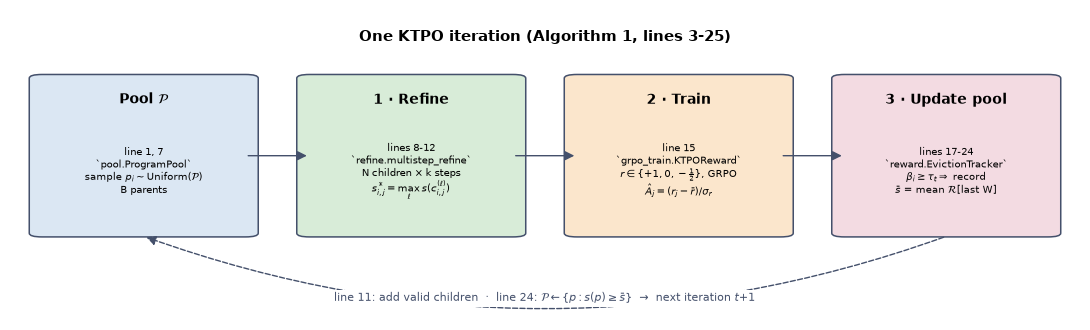

In [18]:
from ktpo import viz
fig, ax = plt.subplots(figsize=(11, 3.4)); viz.cycle_diagram(ax); plt.tight_layout(); plt.show()

## 6 · Inference-only KTPO search (Algorithm 1 without the Train phase)

The full loop with the frozen API model: T iterations × B parents × N children × k steps. Every valid intermediate program joins the pool; β, τ_t, the rolling buffer and eviction run exactly as in Sec. 3.3. This mirrors the paper's *"Learning vs inference-only search"* control (Sec. 4.3) and produces the pool-size and best-score curves of Fig. 2. Budget here: T=8, B=2, N=2, k=3 → 96 LLM calls (the paper: T=50, B=16, N=16, k=8 ≈ 100k calls on 8×H100).

### GPU job first: the Train phase is independent of this search

§7 trains the local policy from the seed program (`GRPO_FROM_POOL=0`, the default), so it does not depend on the search below. The search is API-bound and the training is GPU-bound, so we start the GPU job **now** as a background subprocess and collect its log in §7; this is the only place in the notebook that touches the GPU. If less than 12 GB of GPU memory is free, the step count falls back from 40 to 20.

In [19]:
free_mb = int(subprocess.run(["nvidia-smi", "--query-gpu=memory.free", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True).stdout.split()[0])
STEPS = 4 if QUICK else (40 if free_mb >= 12000 else 20)
GEN = 4 if QUICK else 8
grpo_out = OUT / "grpo"
print(f"GPU free memory: {free_mb} MB → GRPO steps = {STEPS}" + ("" if (QUICK or free_mb >= 12000) else "  (FALLBACK: <12 GB free, 40 → 20 steps)"))

# Parents: the seed program p0 by default (Appendix B setting: training vs inference-only from the same
# initial program). Set GRPO_FROM_POOL=1 to sample parents from the §6 search pool instead (Alg. 1 proper);
# with parents already at ~2.3 the 1.5B model cannot earn +1, so the seed gives a more informative curve.
GRPO_FROM_POOL = os.environ.get("GRPO_FROM_POOL", "0") == "1"
pool_args = ["--pool", str(OUT / "search_pool.jsonl")] if GRPO_FROM_POOL else []
grpo_cmd = [sys.executable, "-m", "ktpo.grpo_train", "--steps", str(STEPS), "--num-generations", str(GEN),
            "--max-completion-length", "1536", *pool_args, "--out", str(grpo_out)]
print(" ".join(grpo_cmd))
grpo_log_path = OUT / "grpo_stdout.log"
if GRPO_FROM_POOL:
    grpo_proc, grpo_t0 = None, None
    print("GRPO_FROM_POOL=1 → the job needs the §6 pool, so it is started in §7 instead")
else:
    grpo_t0 = time.time()
    grpo_proc = subprocess.Popen(grpo_cmd, stdout=open(grpo_log_path, "w"), stderr=subprocess.STDOUT,
                                 env={**os.environ, "TQDM_DISABLE": "1"})
    print(f"started in the background (pid {grpo_proc.pid}); log → {grpo_log_path}")

GPU free memory: 18580 MB → GRPO steps = 40
/mnt/berstorage/RCP/rcp-platform/.venv/bin/python -m ktpo.grpo_train --steps 40 --num-generations 8 --max-completion-length 1536 --out /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/grpo
started in the background (pid 1089961); log → /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/grpo_stdout.log


In [20]:
from ktpo.search import ktpo_search
cfg = dict(T=3, B=1, N=2, k=2) if QUICK else dict(T=8, B=2, N=2, k=3)
print("config", cfg, "→", cfg["T"] * cfg["B"] * cfg["N"] * cfg["k"], "LLM calls")
search_t0 = time.time()
pool, logs = ktpo_search(SEED_PROGRAM, seed_result.score, **cfg, use_pool=True, use_eviction=True, rng_seed=0)
search_secs = time.time() - search_t0
print(f"search wall-clock {search_secs/60:.1f} min")

config {'T': 8, 'B': 2, 'N': 2, 'k': 3} → 96 LLM calls


iter 1: τ=0.26 best=2.2467 avg_best_of_k=1.367 pool=3 evicted=2 s̄=0.9598 β=[0.5, 0.5] (158s)


iter 2: τ=0.22 best=2.2870 avg_best_of_k=1.422 pool=8 evicted=1 s̄=0.9598 β=[1.0, 0.0] (195s)


iter 3: τ=0.19 best=2.2870 avg_best_of_k=1.945 pool=17 evicted=1 s̄=1.1743 β=[1.0, 1.0] (148s)


iter 4: τ=0.15 best=2.5068 avg_best_of_k=2.177 pool=27 evicted=0 s̄=1.3524 β=[1.0, 1.0] (227s)


iter 5: τ=0.11 best=2.5068 avg_best_of_k=2.013 pool=31 evicted=1 s̄=1.4361 β=[1.0, 0.0] (134s)


iter 6: τ=0.08 best=2.6156 avg_best_of_k=1.766 pool=38 evicted=0 s̄=1.4986 β=[0.0, 1.0] (168s)


iter 7: τ=0.04 best=2.6156 avg_best_of_k=1.699 pool=44 evicted=0 s̄=1.5154 β=[1.0, 0.0] (149s)


iter 8: τ=0.00 best=2.6156 avg_best_of_k=1.730 pool=41 evicted=10 s̄=1.7159 β=[1.0, 0.0] (176s)
search wall-clock 22.6 min


,iteration,size,best,mean,evicted,threshold
0,1,3,2.246656,1.600183,2,0.959764
1,2,8,2.287021,1.703681,1,0.959764
2,3,17,2.287021,1.859142,1,1.174344
3,4,27,2.506766,1.925465,0,1.352416
4,5,31,2.506766,1.957814,1,1.436060
5,6,38,2.615593,1.994819,0,1.498619
6,7,44,2.615593,2.019424,0,1.515406
7,8,41,2.615593,2.145815,10,1.715931


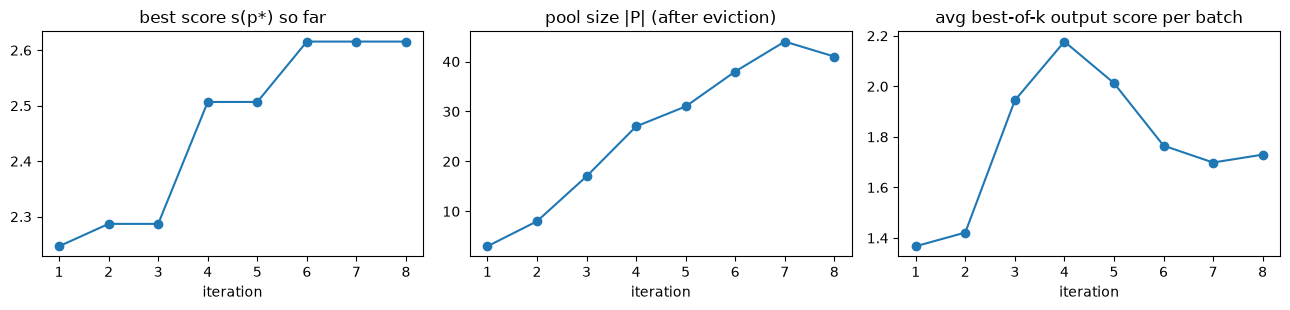

,t,τ_t,parent scores,β,mastered,rewards,s̄,evicted
0,1,0.26,"[0.96, 0.96]","[0.5, 0.5]","[True, True]","[[0.0, 1.0], [0.0, 1.0]]",0.960,2
1,2,0.22,"[0.96, 1.594]","[1.0, 0.0]","[True, False]","[[1.0, 1.0], [0.0, 0.0]]",0.960,1
2,3,0.19,"[1.419, 1.573]","[1.0, 1.0]","[True, True]","[[1.0, 1.0], [1.0, 1.0]]",1.174,1
3,4,0.15,"[1.936, 1.659]","[1.0, 1.0]","[True, True]","[[1.0, 1.0], [1.0, 1.0]]",1.352,0
4,5,0.11,"[2.022, 2.077]","[1.0, 0.0]","[True, False]","[[1.0, 1.0], [0.0, 0.0]]",1.436,1
5,6,0.08,"[2.236, 1.999]","[0.0, 1.0]","[False, True]","[[0.0, -0.5], [1.0, 1.0]]",1.499,0
6,7,0.04,"[1.666, 2.117]","[1.0, 0.0]","[True, False]","[[1.0, 1.0], [-0.5, 0.0]]",1.515,0
7,8,0.00,"[1.936, 1.988]","[1.0, 0.0]","[True, True]","[[1.0, 1.0], [0.0, -0.5]]",1.716,10


best program score: 2.6156


16928

In [21]:
hist = df(pool.history); display(hist)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(hist["iteration"], hist["best"], marker="o"); axes[0].set(title="best score s(p*) so far", xlabel="iteration")
axes[1].plot(hist["iteration"], hist["size"], marker="o"); axes[1].set(title="pool size |P| (after eviction)", xlabel="iteration")
axes[2].plot([l.t for l in logs], [l.avg_best_of_k for l in logs], marker="o"); axes[2].set(title="avg best-of-k output score per batch", xlabel="iteration")
plt.tight_layout(); plt.show()
rows = [{"t": l.t, "τ_t": round(l.tau_t, 2), "parent scores": [round(p["score"], 3) for p in l.parents], "β": [p["beta"] for p in l.parents], "mastered": [p["mastered"] for p in l.parents], "rewards": [p["rewards"] for p in l.parents], "s̄": None if l.threshold is None else round(l.threshold, 3), "evicted": l.evicted} for l in logs]
display(df(rows))
print("best program score:", round(pool.best.score, 4))
(OUT / "search_pool.jsonl").write_text("".join(json.dumps({"src": p.src, "score": p.score}) + "\n" for p in pool.programs.values()))
(OUT / "search_logs.json").write_text(json.dumps([l.__dict__ for l in logs], indent=1, default=str))

### 6a · What the pool does, iteration by iteration

Three views of the same run. **(i) Pool snapshot** — the top-5 programs after each iteration's eviction, with the iteration each was born in and whether it is still the seed. **(ii) Eviction ledger** — the rolling buffer R (Alg. 1 l.20), the threshold s̄ = mean(R[last W]) (l.23) and exactly which scores were dropped by `P ← {p : s(p) ≥ s̄}` (l.24); every evicted score is below s̄ by construction, and the current best is always kept so P can never empty. **(iii) Per-child trajectories** — for one iteration, the k step scores of every child, its s\*, the eq. (1) reward and the group-normalised advantage that GRPO would apply to that rollout.

In [22]:
snap = []
for l in logs:
    row = {"t": l.t, "|P|": l.pool_size, "added (l.11)": l.added}
    for rank, p in enumerate(l.top, 1):
        row[f"#{rank}"] = f"{p['score']:.4f} ({p['origin']}, t={p['born_at']})"
    snap.append(row)
display(df(snap).fillna("—"))

,t,|P|,added (l.11),#1,#2,#3,#4,#5
0,1,3,4,"2.2467 (child, t=1)","1.5941 (child, t=1)","0.9598 (seed, t=0)",—,—
1,2,8,6,"2.2870 (child, t=2)","2.2467 (child, t=1)","1.9807 (child, t=2)","1.5941 (child, t=1)","1.5734 (child, t=2)"
2,3,17,10,"2.2870 (child, t=2)","2.2467 (child, t=1)","2.0340 (child, t=3)","2.0216 (child, t=3)","2.0196 (child, t=3)"
3,4,27,10,"2.5068 (child, t=4)","2.2870 (child, t=2)","2.2613 (child, t=4)","2.2467 (child, t=1)","2.1628 (child, t=4)"
4,5,31,5,"2.5068 (child, t=4)","2.2870 (child, t=2)","2.2727 (child, t=5)","2.2613 (child, t=4)","2.2467 (child, t=1)"
5,6,38,7,"2.6156 (child, t=6)","2.6071 (child, t=6)","2.5068 (child, t=4)","2.3292 (child, t=6)","2.2870 (child, t=2)"
6,7,44,6,"2.6156 (child, t=6)","2.6071 (child, t=6)","2.5068 (child, t=4)","2.4269 (child, t=7)","2.4042 (child, t=7)"
7,8,41,7,"2.6156 (child, t=6)","2.6137 (child, t=8)","2.6071 (child, t=6)","2.5834 (child, t=8)","2.5786 (child, t=8)"


In [23]:
ledger = [{"t": l.t, "τ_t": round(l.tau_t, 3),
           "β per parent": [round(p["beta"], 2) for p in l.parents],
           "mastered → R": [round(p["score"], 3) for p in l.parents if p["mastered"]],
           "R (rolling buffer)": [round(x, 3) for x in l.buffer[-10:]],
           "s̄ = mean(R)": None if l.threshold is None else round(l.threshold, 4),
           "n evicted": l.evicted, "evicted scores (all < s̄)": l.evicted_scores[:6]} for l in logs]
display(df(ledger))

,t,τ_t,β per parent,mastered → R,R (rolling buffer),s̄ = mean(R),n evicted,evicted scores (all < s̄)
0,1,0.263,"[0.5, 0.5]","[0.96, 0.96]","[0.96, 0.96]",0.9598,2,"[0.4881, 0.4881]"
1,2,0.225,"[1.0, 0.0]",[0.96],"[0.96, 0.96, 0.96]",0.9598,1,[0.7129]
2,3,0.188,"[1.0, 1.0]","[1.419, 1.573]","[0.96, 0.96, 0.96, 1.419, 1.573]",1.1743,1,[0.9598]
3,4,0.150,"[1.0, 1.0]","[1.936, 1.659]","[0.96, 0.96, 0.96, 1.419, 1.573, 1.936, 1.659]",1.3524,0,[]
4,5,0.112,"[1.0, 0.0]",[2.022],"[0.96, 0.96, 0.96, 1.419, 1.573, 1.936, 1.659,...",1.4361,1,[1.419]
5,6,0.075,"[0.0, 1.0]",[1.999],"[0.96, 0.96, 0.96, 1.419, 1.573, 1.936, 1.659,...",1.4986,0,[]
6,7,0.037,"[1.0, 0.0]",[1.666],"[0.96, 0.96, 0.96, 1.419, 1.573, 1.936, 1.659,...",1.5154,0,[]
7,8,0.000,"[1.0, 0.0]","[1.936, 1.988]","[0.96, 1.419, 1.573, 1.936, 1.659, 2.022, 1.99...",1.7159,10,"[1.667, 1.6665, 1.6588, 1.6358, 1.5941, 1.5734]"


In [24]:
# the most informative iteration = the one whose children were not all rewarded the same
def spread(l): return len({r for p in l.parents for r in p["rewards"]})
pick = max(logs, key=lambda l: (spread(l), l.t))
rows = []
for p in pick.parents:
    for j, (ts, sstar, r, a) in enumerate(zip(p["traj_scores"], p["best_children"], p["rewards"], p["advantages"])):
        rows.append({"parent": p["pid"], "s(p_i)": round(p["score"], 4), "child j": j,
                     **{f"s(c^{l+1})": round(s, 4) for l, s in enumerate(ts)},
                     "s* = max_ℓ": round(sstar, 4), "r_j (eq. 1)": r, "Â_j": round(a, 3)})
md(f"**Iteration t={pick.t}** · τ_t={pick.tau_t:.3f} · β={[round(p['beta'], 2) for p in pick.parents]} "
   f"· mastered={[p['mastered'] for p in pick.parents]} · s̄={pick.threshold and round(pick.threshold, 4)}")
display(df(rows))

**Iteration t=8** · τ_t=0.000 · β=[1.0, 0.0] · mastered=[True, True] · s̄=1.7159

,parent,s(p_i),child j,s(c^1),s(c^2),s(c^3),s* = max_ℓ,r_j (eq. 1),Â_j
0,e008446b,1.9364,0,2.5834,2.5786,2.5341,2.5834,1.0,0.0
1,e008446b,1.9364,1,0.0000,0.9960,2.6137,2.6137,1.0,0.0
2,9ae51c14,1.9884,0,1.7224,0.0000,1.5715,1.7224,0.0,1.0
3,9ae51c14,1.9884,1,0.0000,0.0000,0.0000,0.0000,-0.5,-1.0


### 6b · Ablations (Sec. 4.3)

Three variants at the **same LLM-call budget** as §6, run concurrently (they are independent):

| variant | switch | paper result (Circle Packing, 102k evals) |
|---|---|---|
| no pool | `use_pool=False` — always refine p₀ | 2.624 ± 0.004 vs 2.635 full |
| no eviction | `use_eviction=False` — P grows unboundedly | 2.616 ± 0.008; pool grows to ~60,000 vs ~1,300 |
| k=1, 3× children | `k=1, N=3N` — same call budget, no sequential revision | 2.613 ± 0.017 vs 2.635 at matched compute |

They run by default in a full run (`NB_ABLATIONS=0` to skip) and are skipped in QUICK mode, where three iterations cannot separate anything. Even at this budget the comparison is a single seed of 96 calls each, so read the curves as mechanism checks, not as measurements.

In [25]:
RUN_ABLATIONS = (not QUICK) and os.environ.get("NB_ABLATIONS", "1") == "1"
ablations = {"no_pool": dict(cfg, use_pool=False, workers=4),
             "no_eviction": dict(cfg, use_eviction=False, workers=4),
             f"k=1 (N×{cfg['k']})": dict(cfg, N=cfg["N"] * cfg["k"], k=1, workers=6)}
abl_results = {}
if RUN_ABLATIONS:
    from concurrent.futures import ThreadPoolExecutor
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=3) as ex:
        futs = {name: ex.submit(ktpo_search, SEED_PROGRAM, seed_result.score, rng_seed=0, verbose=False, **kw)
                for name, kw in ablations.items()}
        for name, fut in futs.items():
            p_, l_ = fut.result()
            abl_results[name] = {"hist": df(p_.history), "logs": l_, "pool": p_}
            print(f"{name:16s} best={p_.best.score:.4f} |P|={len(p_)} calls={sum(x.llm_calls for x in l_)}")
    print(f"ablations wall-clock {(time.time()-t0)/60:.1f} min (3 searches in parallel)")
else:
    print("skipped (QUICK mode or NB_ABLATIONS=0)")

no_pool          best=2.5846 |P|=31 calls=96


no_eviction      best=2.6278 |P|=66 calls=96
k=1 (N×3)        best=2.6360 |P|=24 calls=96
ablations wall-clock 32.9 min (3 searches in parallel)


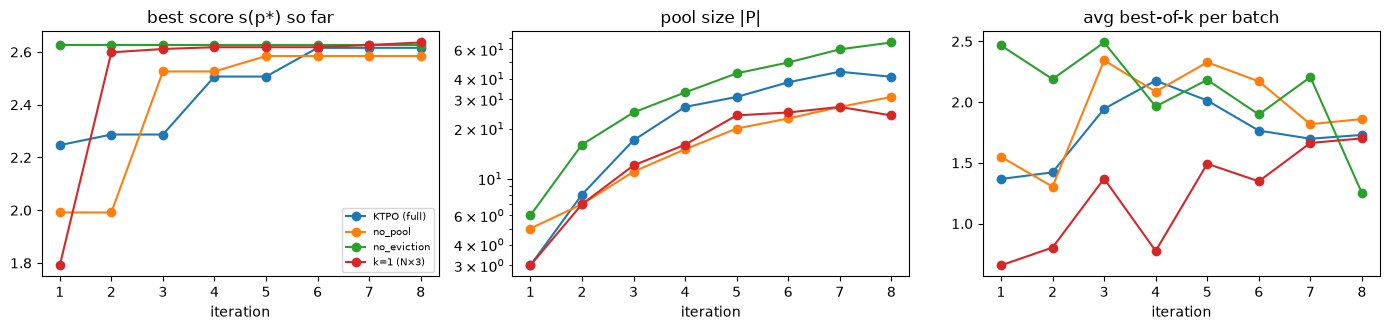

,variant,best s(p*),final |P|,programs added,evicted total,LLM calls,avg best-of-k (mean over t),wall-clock min
0,KTPO (full),2.6156,41,55,15,96,1.7647,22.6
1,no_pool,2.5846,31,37,7,96,1.9326,25.2
2,no_eviction,2.6278,66,65,0,96,2.0811,32.9
3,k=1 (N×3),2.6360,24,48,25,96,1.2262,22.7


In [26]:
if abl_results:
    all_runs = {"KTPO (full)": {"hist": hist, "logs": logs, "pool": pool}, **abl_results}
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
    for name, r_ in all_runs.items():
        h, ls = r_["hist"], r_["logs"]
        axes[0].plot(h["iteration"], h["best"], marker="o", label=name)
        axes[1].plot(h["iteration"], h["size"], marker="o", label=name)
        axes[2].plot([l.t for l in ls], [l.avg_best_of_k for l in ls], marker="o", label=name)
    axes[0].set(title="best score s(p*) so far", xlabel="iteration"); axes[0].legend(fontsize=7)
    axes[1].set(title="pool size |P|", xlabel="iteration"); axes[1].set_yscale("log")
    axes[2].set(title="avg best-of-k per batch", xlabel="iteration")
    plt.tight_layout(); plt.show()
    display(df([{"variant": name,
                 "best s(p*)": round(r_["pool"].best.score, 4),
                 "final |P|": len(r_["pool"]),
                 "programs added": sum(l.added for l in r_["logs"]),
                 "evicted total": sum(l.evicted for l in r_["logs"]),
                 "LLM calls": sum(l.llm_calls for l in r_["logs"]),
                 "avg best-of-k (mean over t)": round(sum(l.avg_best_of_k for l in r_["logs"]) / len(r_["logs"]), 4),
                 "wall-clock min": round(sum(l.seconds for l in r_["logs"]) / 60, 1)} for name, r_ in all_runs.items()]))

### 6c · The best packing found (paper Fig. 4)

The program with the highest s(p) in the pool, re-run to recover its (centers, radii) and drawn in the unit square next to the seed p₀. The paper's best is Σr = 2.63598; this run is four orders of magnitude smaller in LLM calls.

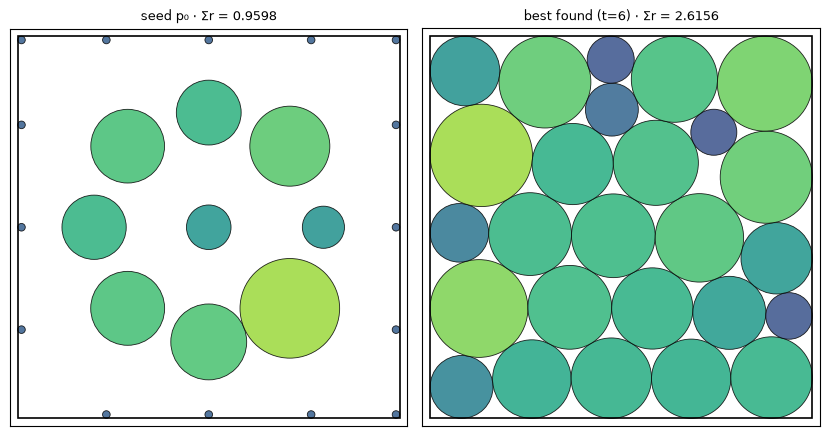

radii: min=0.0602 max=0.1339 distinct=26 | paper best 2.63598, human record 2.634


7996

In [27]:
best_prog = pool.best
c0, r0 = viz.packing_of(SEED_PROGRAM)
try:
    cb, rb = viz.packing_of(best_prog.src)          # re-run the winner to recover its geometry
except Exception as exc:                             # a slow program can time out under load
    print("re-run failed:", exc, "→ falling back to the second best")
    best_prog = sorted(pool.programs.values(), key=lambda q: -q.score)[1]
    cb, rb = viz.packing_of(best_prog.src)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.3))
viz.plot_packing(c0, r0, axes[0], f"seed p₀ · Σr = {r0.sum():.4f}")
viz.plot_packing(cb, rb, axes[1], f"best found (t={best_prog.iteration}) · Σr = {rb.sum():.4f}")
plt.tight_layout(); plt.show()
print(f"radii: min={rb.min():.4f} max={rb.max():.4f} distinct={len(set(rb.round(4)))} | paper best 2.63598, human record 2.634")
(OUT / "best_program.py").write_text(best_prog.src)

## 7 · Real GRPO run (the Train phase) on the local GPU

The paper trains Qwen3-4B / Qwen3.5-9B on 8×H100 with B=16 parents × N=16 children × k=8 steps. Appendix B shows the mechanism also works for a 1.5B model with k=1. Here `ktpo/grpo_train.py` runs TRL's `GRPOTrainer` with **Qwen2.5-Coder-1.5B-Instruct + LoRA** on the RTX A4500: one parent group of N children per optimizer step, the improvement reward of eq. (1) computed by the real evaluator, DAPO clip-higher ε∈[0.2,0.28], no KL term.

A probe before training showed the untuned 1.5B model emits a *valid* packing only ~15–25% of the time (most completions crash), so the reward is mostly −0.5 with some 0s: exactly the regime where the improvement reward teaches validity first. The prompt carries the paper's App. D scaffold plus a short engineering hint for the small model (`SMALL_MODEL_HINT`, disable with `--no-hint`); the evaluator re-attaches OpenEvolve's fixed `run_packing()` entry point if a rewrite dropped it (the benchmark defines that part as non-evolved).

Expected outcome: the pipeline runs end to end and the valid-rate / mean-reward curves move over 40 steps (~45 min). It will **not** approach 2.63 — that needs the paper's compute.

In [28]:
if grpo_proc is None:                      # GRPO_FROM_POOL=1: run it now, synchronously
    grpo_t0 = time.time()
    grpo_proc = subprocess.Popen(grpo_cmd, stdout=open(grpo_log_path, "w"), stderr=subprocess.STDOUT,
                                 env={**os.environ, "TQDM_DISABLE": "1"})

def grpo_progress():
    # complete lines of the background job's log worth printing (HF's tqdm bar can prefix one of them)
    txt = grpo_log_path.read_text()
    txt = txt[:txt.rfind("\n") + 1]         # drop a half-written trailing line
    out = []
    for l in txt.splitlines():
        i = l.find("[reward]")
        if i >= 0:
            out.append(l[i:])
        elif l.startswith("pool:") or "done in" in l:
            out.append(l.strip())
    return out


seen = 0
while True:                                 # tail the background job until it exits
    lines = grpo_progress()
    for l in lines[seen:]:
        print(l, flush=True)
    seen = len(lines)
    if grpo_proc.poll() is not None:
        break
    time.sleep(20)
rc = grpo_proc.wait()
for l in grpo_progress()[seen:]:
    print(l)
if rc != 0:
    print("\n".join(grpo_log_path.read_text().splitlines()[-25:]))
print(f"wall-clock {(time.time()-grpo_t0)/60:.1f} min (overlapped with §6), exit {rc}")

pool: 1 parents, scores [0.96]


[reward] step 1: reward_mean=-0.312 valid=0.38 best_in_batch=0.8425 best_so_far=0.8425 (52s)


[reward] step 2: reward_mean=-0.312 valid=0.38 best_in_batch=0.2561 best_so_far=0.8425 (111s)


[reward] step 3: reward_mean=-0.312 valid=0.38 best_in_batch=0.5913 best_so_far=0.8425 (168s)


[reward] step 4: reward_mean=-0.312 valid=0.38 best_in_batch=0.9480 best_so_far=0.9480 (244s)


...

[reward] step 38: reward_mean=-0.250 valid=0.50 best_in_batch=0.9598 best_so_far=1.2393 (2888s)


[reward] step 39: reward_mean=-0.375 valid=0.25 best_in_batch=0.9598 best_so_far=1.2393 (3020s)


[reward] step 40: reward_mean=-0.188 valid=0.62 best_in_batch=0.6953 best_so_far=1.2393 (3072s)


done in 3077s; adapter saved to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/grpo/adapter


wall-clock 55.5 min (overlapped with §6), exit 0


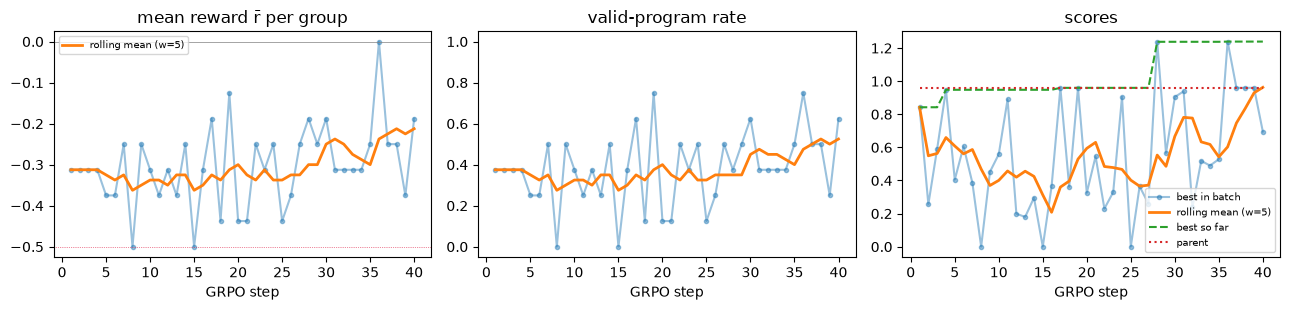

,step,parent_score,reward_mean,valid_rate,improve_rate,best_in_batch,best_so_far,seconds
0,1,0.959764,-0.3125,0.375,0.000,8.425033e-01,0.842503,51.7
1,2,0.959764,-0.3125,0.375,0.000,2.561001e-01,0.842503,111.3
2,3,0.959764,-0.3125,0.375,0.000,5.913075e-01,0.842503,167.7
3,4,0.959764,-0.3125,0.375,0.000,9.480409e-01,0.948041,244.0
4,5,0.959764,-0.3750,0.250,0.000,4.046982e-01,0.948041,323.0
5,6,0.959764,-0.3750,0.250,0.000,6.056469e-01,0.948041,381.8
6,7,0.959764,-0.2500,0.500,0.000,3.862159e-01,0.948041,448.9
7,8,0.959764,-0.5000,0.000,0.000,0.000000e+00,0.948041,508.9
8,9,0.959764,-0.2500,0.500,0.000,4.527433e-01,0.948041,566.1
9,10,0.959764,-0.3125,0.375,0.000,5.587598e-01,0.948041,628.0


first half: reward -0.331, valid 0.34 | second half: reward -0.275, valid 0.42
LoRA adapter saved: True | trainer log entries: 41


In [29]:
metrics = [json.loads(l) for l in (grpo_out / "metrics.jsonl").read_text().splitlines() if l.strip()]
m = df(metrics)
w = max(2, min(5, len(m) // 4))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(m["step"], m["reward_mean"], marker=".", alpha=0.45)
axes[0].plot(m["step"], m["reward_mean"].rolling(w, min_periods=1).mean(), lw=2, label=f"rolling mean (w={w})")
axes[0].axhline(0, color="gray", lw=0.5); axes[0].axhline(-0.5, color="crimson", lw=0.5, ls=":")
axes[0].set(title="mean reward r̄ per group", xlabel="GRPO step"); axes[0].legend(fontsize=7)
axes[1].plot(m["step"], m["valid_rate"], marker=".", alpha=0.45)
axes[1].plot(m["step"], m["valid_rate"].rolling(w, min_periods=1).mean(), lw=2)
axes[1].set(title="valid-program rate", xlabel="GRPO step", ylim=(-0.05, 1.05))
axes[2].plot(m["step"], m["best_in_batch"], marker=".", alpha=0.45, label="best in batch")
axes[2].plot(m["step"], m["best_in_batch"].rolling(w, min_periods=1).mean(), lw=2, label=f"rolling mean (w={w})")
axes[2].plot(m["step"], m["best_so_far"], ls="--", label="best so far")
axes[2].plot(m["step"], m["parent_score"], ls=":", label="parent")
axes[2].set(title="scores", xlabel="GRPO step"); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
display(m[["step", "parent_score", "reward_mean", "valid_rate", "improve_rate", "best_in_batch", "best_so_far", "seconds"]])
half = len(m) // 2
print(f"first half: reward {m.reward_mean[:half].mean():+.3f}, valid {m.valid_rate[:half].mean():.2f} | "
      f"second half: reward {m.reward_mean[half:].mean():+.3f}, valid {m.valid_rate[half:].mean():.2f}")
print("LoRA adapter saved:", (grpo_out / "adapter").exists(), "| trainer log entries:", len(json.loads((grpo_out / "train_log.json").read_text())))

## 8 · Training vs inference-only (Sec. 4.3 / Fig. 3a, in miniature)

The paper's control compares the *average best-of-k output score per batch* with and without GRPO updates at matched LLM evaluations. Below: the frozen API model's per-iteration average (from §6, plus the no-pool/no-eviction/k=1 variants of §6b) next to the small local model's per-step average (from §7). **This is not compute-matched and the two models differ**, so read it only as "does the training curve trend upward while the frozen one stays flat", which is the paper's qualitative claim.

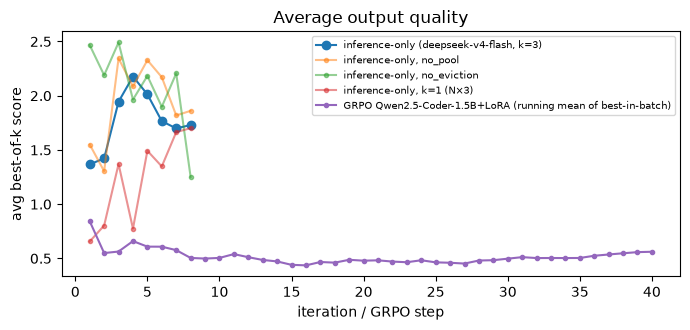

In [30]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(logs) + 1), [l.avg_best_of_k for l in logs], marker="o",
        label=f"inference-only ({common.env()['model'].split('/')[-1]}, k={cfg['k']})")
for name, r_ in abl_results.items():
    ax.plot([l.t for l in r_["logs"]], [l.avg_best_of_k for l in r_["logs"]], marker=".", alpha=0.5, label=f"inference-only, {name}")
ax.plot(m["step"], m["best_in_batch"].expanding().mean(), marker=".",
        label="GRPO Qwen2.5-Coder-1.5B+LoRA (running mean of best-in-batch)")
ax.set(xlabel="iteration / GRPO step", ylabel="avg best-of-k score", title="Average output quality")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

## Summary

| Block | Result of this run |
|---|---|
| Evaluator | seed p₀ scores ≈0.96; invalid programs score 0 with a diagnostic (fail-closed) |
| Pool | uniform sampling, valid-only insertion and threshold eviction behave as in Alg. 1 |
| Reward / advantages | eq. (1) and group normalisation reproduce; all-equal groups give zero signal |
| β / τ_t / R / s̄ | schedule and rolling buffer reproduce Alg. 1 lines 4, 17–24 |
| MultiStepRefine | the frozen model improves the seed within k steps using the verbatim App. D feedback |
| Agentic refine (§5b) | a live pi session reaches a comparable s\* through edit→evaluate→read-feedback tool calls |
| Algorithm 1 map (§5c) | every pseudocode line is bound to a function in `ktpo/` |
| KTPO search (§6) | best score, pool size, per-iteration pool snapshots, rolling buffer and per-child trajectories |
| Ablations (§6b) | no-pool / no-eviction / k=1-at-matched-budget compared against the full loop |
| Best packing (§6c) | the discovered layout drawn against the seed |
| GRPO (§7) | real LoRA training with the improvement reward, run on the GPU alongside §6 |

In [31]:
print(USAGE.summary())

388 requests, 1657156 in / 1001361 out tokens, 13562s in model calls, $0.2792; by tag: {'pi_refine': 1, 'refine': 3, 'refine_t1': 48, 'refine_t2': 48, 'refine_t3': 48, 'refine_t4': 48, 'refine_t5': 48, 'refine_t6': 48, 'refine_t7': 48, 'refine_t8': 48}
